# Shape and Purities Testing for Nuclear Fussion

**Jason Sheppard**

## Research Question

How do different shapes and purities impact our value of $k$? Which has a greater impact?

## Initial Setup

In this simulation we are modeling how neutrons produced from nuclear fussion propagate through a reactors region, either escaping or initiatiting further reactions that create new neutron generations. This allows us to investigate how $k$, is impacted by factors such as goemetric shape, volume and the probabilty of neutrons producing further reactions.

We investigate this by sampling random starting locations within the different shapes and assigning each particle a random travel direction, then determining whether it remains inside the region and induces a subsequent reaction. This process is repeated many times to reduce randomness and isolate the underlying data behavior.

## Defining $k$

$k$ is defined here as the multipulcation factor that represents the ratio of neutrons in one generation to the number in the next generation. $k = N_{i+1}/N_i$

## Assumptions

1. All distance values are in meters.
2. The Volume of all inital shapes is 1000$cm^3$ unless otherwise noted.

## Example Simulation

![](simulationexample.png)

Figure 0: One plot showing the path traced by 3 neutron generations in the XY plane. Each line segment represents a neutrons movement and each color represents a generation. This graph gives us a geometrical idea of how the calculations were done, the fussion must also occur inside the chosen shape of nuclear fuel. 


# Start of Code

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# empty lists to store all data used to graph later
allk01 = []
allk12 = []
allk23 = []

p_data = []
v_data = []

In [29]:
# This function takes a starting position for a neutron, chooses a random direction in 3d space,
# travels a distance of mean_free_path and returns the final position

def simulate_n(start_pos, mean_free_path):
    x0, y0, z0 = start_pos

    phi = np.random.uniform(0, 2 * np.pi)
    costheta = np.random.uniform(-1, 1)
    theta = np.arccos(costheta)

    d = np.random.exponential(mean_free_path)

    xf = x0 + d * np.sin(theta) * np.cos(phi)
    yf = y0 + d * np.sin(theta) * np.sin(phi)
    zf = z0 + d * np.cos(theta)

    return (xf, yf, zf)

In [30]:
# This function repeats the main calculation function a number of 'runs' times,
# and keeps track of all returned values.

def repeat_simulation(runs, N_per_run, v = 1000, mean_free_path = 2.65, p=1):
    k_array01, k_array12, k_array23 = [], [], []
    for i in range(runs): 
        k_list01, k_list12, k_list23 = k_simulation(N_per_run, v, mean_free_path, p)
        
        k_array01.append(k_list01)
        k_array12.append(k_list12)
        k_array23.append(k_list23)

    return np.array(k_array01), np.array(k_array12), np.array(k_array23)

In [31]:
# These two functions are used to simplify printing data and graph
# They are given arrays of k values and print/graph information accordingly

def to_print(k01, k12, k23):
    k01_mean = np.mean(k01)
    k12_mean = np.mean(k12)
    k23_mean = np.mean(k23)
    
    k01_std = np.std(k01)
    k12_std = np.std(k12)
    k23_std = np.std(k23)
    
    print(f'k01 mean = {k01_mean:.3f} ± {k01_std:.3f}')
    print(f'k12 mean = {k12_mean:.3f} ± {k12_std:.3f}')
    print(f'k23 mean = {k23_mean:.3f} ± {k23_std:.3f}')
    

def to_graph(k01, k12, k23, lower=1, upper=2):
    plt.hist(k01, bins=15, edgecolor = 'black', label = 'k01')
    plt.hist(k12, bins=15, edgecolor = 'black', label = 'k12')
    plt.hist(k23, bins=15, edgecolor = 'black', label = 'k23')
    
    plt.xlim(lower, upper)
    plt.legend()
    plt.figtext(0.5, -0.1,
            "Figure 2: Estimated neutron multiplication factor k across generations inside a cylinder, h = r. ",
            ha="center", fontsize=10)
    plt.show()

# Code Break

All the code above is constant regardless of shape. Everything below is slightly tweaked for each shape. (Mainly the inside_shape function)

In [32]:
# This function returns a boolean based on if the location of the neutron is in the desired shape or not
def inside_cube(loc, a):
    x, y, z = loc
    return (0 < x < a) and (0 < y < a) and (0 < z < a)

# This is the main calculation function of the project,
# it is run 'runs' amount of times and each time it simulates 'N, neutrons
# and returns multiplication factor value between each generation.
# mean_free_path is not changed in this project but p is. 
# P is the probability of further fission and will range from 0.1-1 later on

def k_simulation(N, v, mean_free_path, p):
    # starting empty values
    N0 = 0
    N1 = 0
    N2 = 0
    N3 = 0
    gen1_finals = []
    gen2_finals = []

    # Side length for the shape based on a (constant) volume - Cube in this case
    a = v ** (1/3)

    # arb is arbitrary, Repeats N times
    for arb in range(N):
        # generating stating neutron location
        x0 = np.random.uniform(0, a)
        y0 = np.random.uniform(0, a)
        z0 = np.random.uniform(0, a)
    
        i0 = (x0, y0, z0)
        # simulating direction and motion
        f0 = simulate_n(i0, mean_free_path)

        # checking if it stayed inside the shape and if it initiates further fission
        if inside_cube(f0, a) and np.random.rand() < p:
            # keeping track of stats
            N0 += 1
            
            # each generation 0 produces 2 generation 1s
            for arb in range(2):
                f1 = simulate_n(f0, mean_free_path)
                
                # checking if new gen1s stayed inside the shape and initiate further
                if inside_cube(f1, a) and np.random.rand() < p:
                    # keep track of stats and final position for next generation
                    N1 += 1
                    gen1_finals.append(f1)

    
    # for all final gen 1 positions that stayed inside the shape and initiated,
    for each in gen1_finals:
        # each generation 1 produces 2 generation 2s
        for arb in range(2):
            f2 = simulate_n(each, mean_free_path)
            # checking if new gen2s stayed inside the shape and initiate further
            if inside_cube(f2, a) and np.random.rand() < p:
                # tracking stats and final position for next generation
                N2 += 1
                gen2_finals.append(f2)


    
    # for all final gen 2 positions that stayed inside the shape and initiated,
    for each in gen2_finals:
        # each generation 2 produces 2 generation 3s
        for arb in range(2):
            f3 = simulate_n(each, mean_free_path)
            # checking if new gen3s stayed inside the shape and initiate further
            if inside_cube(f3, a) and np.random.rand() < p:
                # tracking stats only - no next generation
                N3 += 1



    # calculating k factor value for between each generation
    k_val01 = N1 / N0 if N0 > 0 else 0
    k_val12 = N2 / N1 if N1 > 0 else 0
    k_val23 = N3 / N2 if N2 > 0 else 0
        
        


    
    return k_val01, k_val12, k_val23

Shape is a cube with Volume of 1000 and side length a = 10
k01 mean = 1.425 ± 0.048
k12 mean = 1.446 ± 0.040
k23 mean = 1.469 ± 0.036


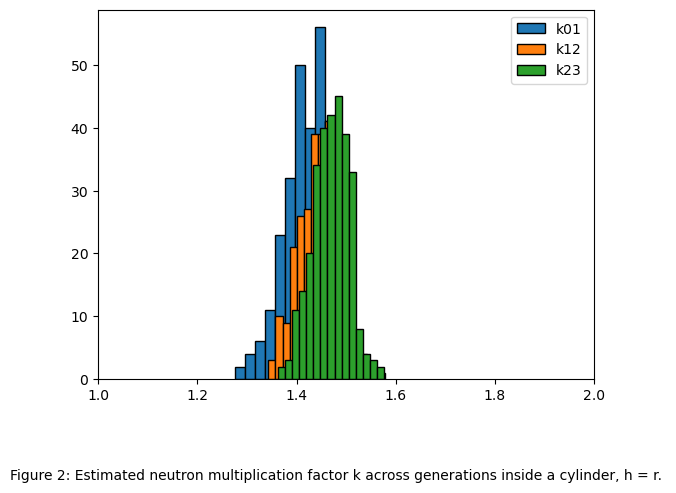

In [33]:
# This window is to show a graph of the shape and also calculate k values for different p values
# Running the sim once
k01, k12, k23 = repeat_simulation(300, 250)

print(f'Shape is a cube with Volume of 1000 and side length a = 10')
to_print(k01, k12, k23)
to_graph(k01, k12, k23)

# To be graphed later
allk01.append(k01)
allk12.append(k12)
allk23.append(k23)

# iterates 10 times, ranging through p values
for i in range(10):
    p = i/10 + 0.1 # min of 0.1 max of 1

    k01, k12, k23 = repeat_simulation(150, 250, 1000, 2.65, p)
    k01_mean = np.mean(k01)
    k12_mean = np.mean(k12)
    k23_mean = np.mean(k23)

    # averaging out all k_means for data simplicity (they are all around the same value)
    val = (k01_mean + k12_mean + k23_mean) / 3
    # saving for later
    p_data.append([val, p])

# Code Break

Above was all the required code for a cube. There are only 3 changes between the first code break and here. One is the name of the inside_shape function being called in the k_simulation function. Both other changes will be noted inside the code.

In [34]:
# New boolean based function that returns if the location of neutron is now inside the SPHERE or not.
def inside_sphere(loc, r):
    x, y, z = loc
    return (x**2 + y**2 + z**2) <= r**2

def k_simulation(N, v, mean_free_path, p):
    N0 = 0
    N1 = 0
    N2 = 0
    N3 = 0
    gen1_finals = []
    gen2_finals = []

    # Calculating radius for sphere based on the same constant volume (1000)
    r = (3 * v / (4 * np.pi)) ** (1/3)

    # arb is arbitrary 
    for arb in range(N):
        x0 = np.random.uniform(-r, r)
        y0 = np.random.uniform(-r, r)
        z0 = np.random.uniform(-r, r)

        i0 = (x0, y0, z0)
        f0 = simulate_n(i0, mean_free_path)

        if inside_sphere(f0, r) and np.random.rand() < p:
            N0 += 1

            for arb in range(2):
                f1 = simulate_n(f0, mean_free_path)
                if inside_sphere(f1, r) and np.random.rand() < p:
                    N1 += 1
                    gen1_finals.append(f1)
    
    
    for each in gen1_finals:
        for arb in range(2):
            f2 = simulate_n(each, mean_free_path)
            if inside_sphere(f2, r) and np.random.rand() < p:
                N2 += 1
                gen2_finals.append(f2)
    
    
    for each in gen2_finals:
        for arb in range(2):
            f3 = simulate_n(each, mean_free_path)
            if inside_sphere(f3, r) and np.random.rand() < p:
                N3 += 1




    k_val01 = N1 / N0 if N0 > 0 else 0
    k_val12 = N2 / N1 if N1 > 0 else 0
    k_val23 = N3 / N2 if N2 > 0 else 0
        
        


    
    return k_val01, k_val12, k_val23

Shape is a sphere with Volume of 1000 and radius r = 6.20
k01 mean = 1.432 ± 0.066
k12 mean = 1.473 ± 0.050
k23 mean = 1.486 ± 0.043


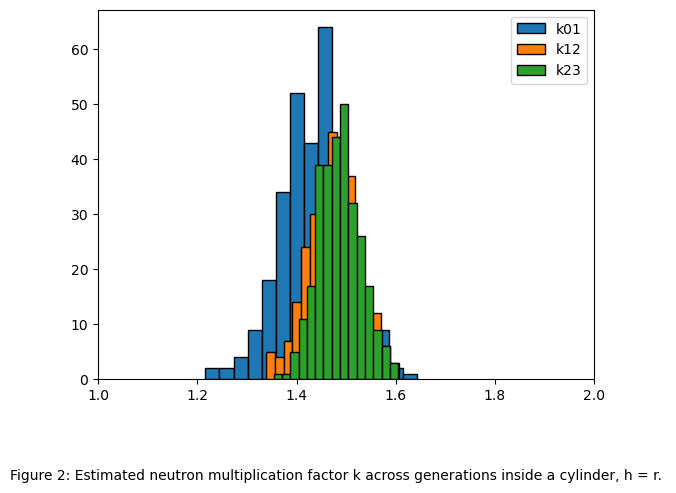

In [35]:
# Everything within this block is constant with above
k01, k12, k23 = repeat_simulation(300, 250)

print(f'Shape is a sphere with Volume of 1000 and radius r = 6.20')
to_print(k01, k12, k23)
to_graph(k01, k12, k23)

allk01.append(k01)
allk12.append(k12)
allk23.append(k23)
for i in range(10):
    p = i/10 + 0.1 # min of 0.1 max of 1
    
    k01, k12, k23 = repeat_simulation(150, 250, 1000, 2.65, p)
    k01_mean = np.mean(k01)
    k12_mean = np.mean(k12)
    k23_mean = np.mean(k23)
    val = (k01_mean + k12_mean + k23_mean) / 3
    p_data.append([val, p])

# Code Break

Now we have another shape. There are two cylinders in this project, one with a height of 10 (cylinder1) and the other with a height equal to radius (cylinder2). Same changes have been made as noted above.

In [36]:
# New logic to check if the neutron is inside a cylinder
def inside_cylinder1(loc, r):
    x, y, z = loc
    h = 10
    return (x**2 + y**2 <= r**2) and (abs(z) <= h/2)

def k_simulation(N, v, mean_free_path, p):
    N0 = 0
    N1 = 0
    N2 = 0
    N3 = 0
    gen1_finals = []
    gen2_finals = []

    # New shape side lengths for a cylinder
    h = 10
    r = np.sqrt(v / (np.pi * h))
    
    

    # arb is arbitrary 
    for arb in range(N):
        x0 = np.random.uniform(-r, r)
        y0 = np.random.uniform(-r, r)
        z0 = np.random.uniform(0, 10)

        i0 = (x0, y0, z0)
        f0 = simulate_n(i0, mean_free_path)

        if inside_cylinder1(f0, r) and np.random.rand() < p:
            N0 += 1

            for arb in range(2):
                f1 = simulate_n(f0, mean_free_path)
                if inside_cylinder1(f1, r) and np.random.rand() < p:
                    N1 += 1
                    gen1_finals.append(f1)
    
    
    for each in gen1_finals:
        for arb in range(2):
            f2 = simulate_n(each, mean_free_path)
            if inside_cylinder1(f2, r) and np.random.rand() < p:
                N2 += 1
                gen2_finals.append(f2)
    
    
    for each in gen2_finals:
        for arb in range(2):
            f3 = simulate_n(each, mean_free_path)
            if inside_cylinder1(f3, r) and np.random.rand() < p:
                N3 += 1




    k_val01 = N1 / N0 if N0 > 0 else 0
    k_val12 = N2 / N1 if N1 > 0 else 0
    k_val23 = N3 / N2 if N2 > 0 else 0
        
        


    
    return k_val01, k_val12, k_val23

Shape is a cylinder with Volume of 1000, radius r = 5.64 and height h = 10
k01 mean = 1.406 ± 0.072
k12 mean = 1.448 ± 0.065
k23 mean = 1.474 ± 0.051


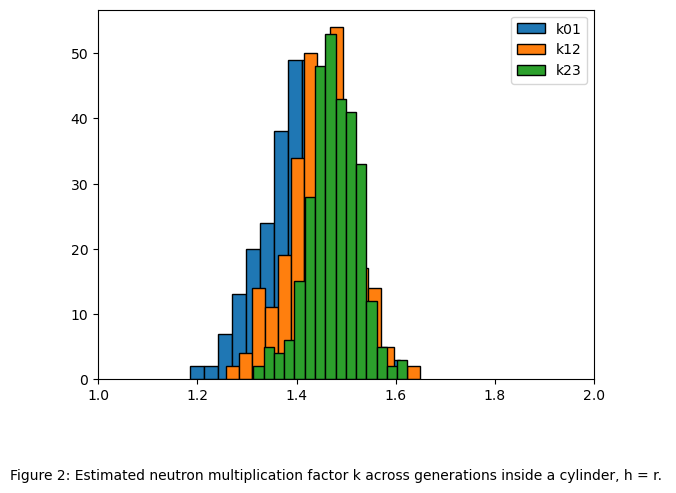

In [37]:
# No changes from above
k01, k12, k23 = repeat_simulation(300, 250)

print(f'Shape is a cylinder with Volume of 1000, radius r = 5.64 and height h = 10')
to_print(k01, k12, k23)
to_graph(k01, k12, k23)

allk01.append(k01)
allk12.append(k12)
allk23.append(k23)

for i in range(10):
    p = i/10 + 0.1 # min of 0.1 max of 1
    
    k01, k12, k23 = repeat_simulation(150, 250, 1000, 2.65, p)
    k01_mean = np.mean(k01)
    k12_mean = np.mean(k12)
    k23_mean = np.mean(k23)
    val = (k01_mean + k12_mean + k23_mean) / 3
    p_data.append([val, p])

In [38]:
# No changes from all other shapes
# same logic as above but h = r instead of 10
def inside_cylinder2(loc, r):
    x, y, z = loc
    h = r
    return (x**2 + y**2 <= r**2) and (abs(z) <= h/2)

def k_simulation(N, v, mean_free_path, p):
    N0 = 0
    N1 = 0
    N2 = 0
    N3 = 0
    gen1_finals = []
    gen2_finals = []

    # setting side lengths for cylinder 2
    r = (v / np.pi) ** (1/3)
    h = r
    
    

    # arb is arbitrary 
    for arb in range(N):
        x0 = np.random.uniform(-r, r)
        y0 = np.random.uniform(-r, r)
        z0 = np.random.uniform(0, 10)

        i0 = (x0, y0, z0)
        f0 = simulate_n(i0, mean_free_path)

        if inside_cylinder2(f0, r) and np.random.rand() < p:
            N0 += 1

            for arb in range(2):
                f1 = simulate_n(f0, mean_free_path)
                if inside_cylinder2(f1, r) and np.random.rand() < p:
                    N1 += 1
                    gen1_finals.append(f1)
    
    
    for each in gen1_finals:
        for arb in range(2):
            f2 = simulate_n(each, mean_free_path)
            if inside_cylinder2(f2, r) and np.random.rand() < p:
                N2 += 1
                gen2_finals.append(f2)
    
    
    for each in gen2_finals:
        for arb in range(2):
            f3 = simulate_n(each, mean_free_path)
            if inside_cylinder2(f3, r) and np.random.rand() < p:
                N3 += 1




    k_val01 = N1 / N0 if N0 > 0 else 0
    k_val12 = N2 / N1 if N1 > 0 else 0
    k_val23 = N3 / N2 if N2 > 0 else 0
        
        


    
    return k_val01, k_val12, k_val23


Shape is a cylinder with Volume of 1000, radius r = 6.84 and height h = 6.84
k01 mean = 1.376 ± 0.092
k12 mean = 1.428 ± 0.072
k23 mean = 1.446 ± 0.065


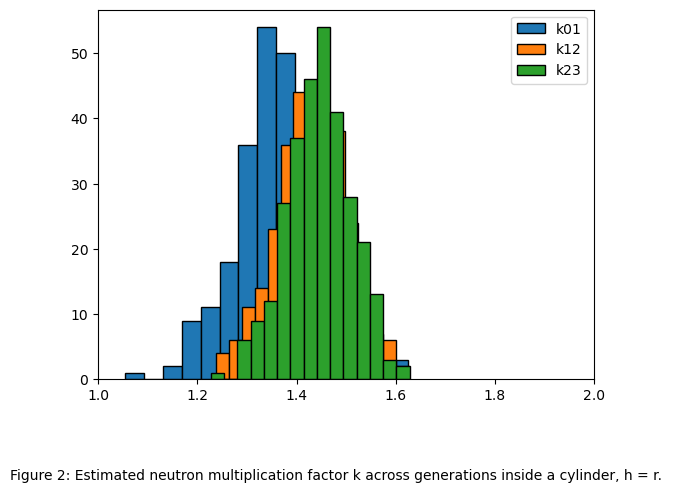

In [39]:
# No changes
k01, k12, k23 = repeat_simulation(300, 250)

print(f'Shape is a cylinder with Volume of 1000, radius r = 6.84 and height h = 6.84')
to_print(k01, k12, k23)
to_graph(k01, k12, k23)

allk01.append(k01)
allk12.append(k12)
allk23.append(k23)

for i in range(10):
    p = i/10 + 0.1 # min of 0.1 max of 1
    
    k01, k12, k23 = repeat_simulation(150, 250, 1000, 2.65, p)
    k01_mean = np.mean(k01)
    k12_mean = np.mean(k12)
    k23_mean = np.mean(k23)
    val = (k01_mean + k12_mean + k23_mean) / 3
    p_data.append([val, p])

# Code Break

Below is an extra calculation that iterates through different volumes and purities for the most idealistic shape as found below.

In [40]:
# Nearly everything within this block is constant with the above code for a SPHERE. 
def inside_sphere(loc, r):
    x, y, z = loc
    return (x**2 + y**2 + z**2) <= r**2

def k_simulation(N, v, mean_free_path, p):
    N0 = 0
    N1 = 0
    N2 = 0
    N3 = 0
    gen1_finals = []
    gen2_finals = []

    # Calculating radius for sphere based on the same constant volume (1000)
    r = (3 * v / (4 * np.pi)) ** (1/3)

    # arb is arbitrary 
    for arb in range(N):
        x0 = np.random.uniform(-r, r)
        y0 = np.random.uniform(-r, r)
        z0 = np.random.uniform(-r, r)

        i0 = (x0, y0, z0)
        f0 = simulate_n(i0, mean_free_path)

        if inside_sphere(f0, r) and np.random.rand() < p:
            N0 += 1

            for arb in range(2):
                f1 = simulate_n(f0, mean_free_path)
                if inside_sphere(f1, r) and np.random.rand() < p:
                    N1 += 1
                    gen1_finals.append(f1)
    
    
    for each in gen1_finals:
        for arb in range(2):
            f2 = simulate_n(each, mean_free_path)
            if inside_sphere(f2, r) and np.random.rand() < p:
                N2 += 1
                gen2_finals.append(f2)
    
    
    for each in gen2_finals:
        for arb in range(2):
            f3 = simulate_n(each, mean_free_path)
            if inside_sphere(f3, r) and np.random.rand() < p:
                N3 += 1




    k_val01 = N1 / N0 if N0 > 0 else 0
    k_val12 = N2 / N1 if N1 > 0 else 0
    k_val23 = N3 / N2 if N2 > 0 else 0
        
        


    
    return k_val01, k_val12, k_val23


# This is a new double nest for loop that iterates through volume and purtiy to see which has a greater impact on K
for j in range(10):
    volume = j*200 + 100 # min of 200, max of 2000
    for i in range(10):
        p = i/10 + 0.1 # min of 0.1 max of 1
        
        k01, k12, k23 = repeat_simulation(150, 250, volume, 2.65, p)
        k01_mean = np.mean(k01)
        k12_mean = np.mean(k12)
        k23_mean = np.mean(k23)
        val = (k01_mean + k12_mean + k23_mean) / 3
        v_data.append([val, p, volume])

# Code Break

Below is the code to graph all the final plots. It has been split up to make it easier to read.

In [41]:
# This function graphs the first 4 graphs.
def graph1(allk01, allk12, allk23):
    f, ax = plt.subplots(2, 2, figsize=(12, 12))


    ax[0][0].hist(allk01[0], bins=15, edgecolor = 'black', label = 'k01')
    ax[0][0].hist(allk12[0], bins=15, edgecolor = 'black', label = 'k12')
    ax[0][0].hist(allk23[0], bins=15, edgecolor = 'black', label = 'k23')
    ax[0][0].set_xlabel("K - Value")
    ax[0][0].set_ylabel("Frequency")
    ax[0][0].set_xlim(1, 2)
    ax[0][0].set_title('Different k values for a Cube')
    ax[0][0].legend()
    
    ax[0][1].hist(allk01[1], bins=15, edgecolor = 'black', label = 'k01')
    ax[0][1].hist(allk12[1], bins=15, edgecolor = 'black', label = 'k12')
    ax[0][1].hist(allk23[1], bins=15, edgecolor = 'black', label = 'k23')
    ax[0][1].set_xlabel("K - Value")
    ax[0][1].set_ylabel("Frequency")
    ax[0][1].set_xlim(1, 2)
    ax[0][1].set_title('Different k values for a Sphere')
    ax[0][1].legend()
    
    ax[1][0].hist(allk01[2], bins=15, edgecolor = 'black', label = 'k01')
    ax[1][0].hist(allk12[2], bins=15, edgecolor = 'black', label = 'k12')
    ax[1][0].hist(allk23[2], bins=15, edgecolor = 'black', label = 'k23')
    ax[1][0].set_xlabel("K - Value")
    ax[1][0].set_ylabel("Frequency")
    ax[1][0].set_xlim(1, 2)
    ax[1][0].set_title('Different k values for a Cylinder, h = 10')
    ax[1][0].legend()
    
    ax[1][1].hist(allk01[3], bins=15, edgecolor = 'black', label = 'k01')
    ax[1][1].hist(allk12[3], bins=15, edgecolor = 'black', label = 'k12')
    ax[1][1].hist(allk23[3], bins=15, edgecolor = 'black', label = 'k23')
    ax[1][1].set_xlabel("K - Value")
    ax[1][1].set_ylabel("Frequency")
    ax[1][1].set_xlim(1, 2)
    ax[1][1].set_title('Different k values for a Cylinder, h = r')
    ax[1][1].legend()
    plt.savefig('graph1.png')
    plt.show()

In [42]:
# This function graphs only the middle graph
def graph2(p_data):
    data = np.array(p_data)
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    d1 = data[0:10]
    d2 = data[10:20]
    d3 = data[20:30]
    d4 = data[30:40]
    
    plt.plot(d1[:, 1], d1[:, 0], label="Cube")
    plt.plot(d2[:, 1], d2[:, 0], label="Sphere")
    plt.plot(d3[:, 1], d3[:, 0], label="Cylinder, h = 10")
    plt.plot(d4[:, 1], d4[:, 0], label="Cylinder, h = r")
    
    
    plt.ylim(0, 1.5)
    
    plt.xlabel("Probability that captured neutrons initiate further fissions, p")
    plt.ylabel("Mean k values (K01, K12, K23 all averaged)")
    plt.title("How p impacts k for all 4 shapes overlapped")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig('graph2.png')
    plt.show()

In [43]:
#This function graphs only the last graph
def graph3(v_data):
    v_data = np.array(v_data)

    # --- Extract columns ---
    k = v_data[:, 0]
    p = v_data[:, 1]
    v = v_data[:, 2]
    
    # --- Get unique grid values ---
    p_unique = np.unique(p)
    v_unique = np.unique(v)
    
    
    # --- Create grid (note order: v = x, p = y) ---
    V, P = np.meshgrid(v_unique, p_unique)
    
    # --- Fill k-values onto grid ---
    K = np.full(P.shape, np.nan)
    
    for ki, pi, vi in zip(k, p, v):
        i = np.where(p_unique == pi)[0][0]   # p-index (row)
        j = np.where(v_unique == vi)[0][0]   # v-index (col)
        K[i, j] = ki
    
    # --- Plot ---
    plt.figure(figsize=(8, 6))
    
    pcm = plt.pcolormesh(
        V, P, K,
        shading="nearest",
        cmap="plasma"
    )
    
    plt.colorbar(pcm, label="k")
    plt.xlabel("Volume")
    plt.ylabel("Purity")
    plt.title("k vs Volume and Purity")
    
    plt.tight_layout()
    plt.savefig('graph3.png')
    plt.show()

# End of Code

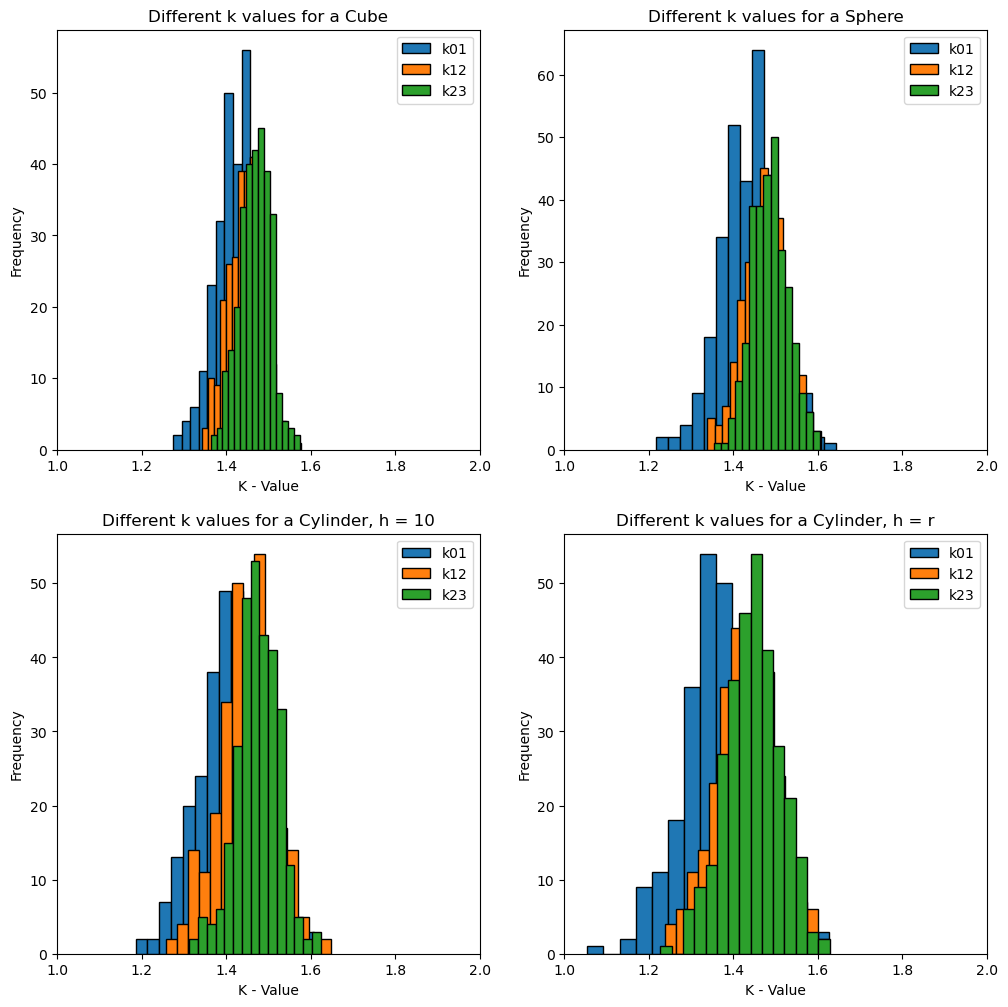

Figure 1: Four histograms showing the neutron multiplication factor k for different shapes (a cube, a sphere, and two cylinders with different heights). The different colors show how k changes from one neutron generation to the next, and the spread of the graphs comes from repeating the simulation many times to see how the shape affects neutron confinement.


In [44]:
# Graphing
graph1(allk01, allk12, allk23)
print("Figure 1: Four histograms showing the neutron multiplication factor k for different shapes (a cube, a sphere, and two cylinders with different heights). The different colors show how k changes from one neutron generation to the next, and the spread of the graphs comes from repeating the simulation many times to see how the shape affects neutron confinement.")

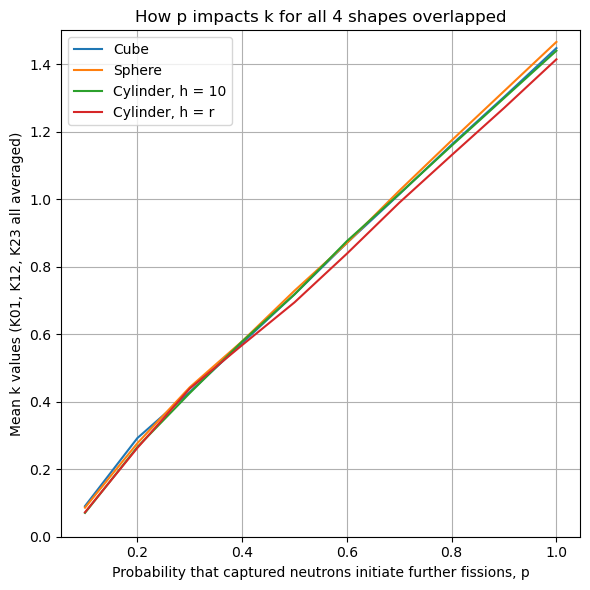

Figure 2: Plot showing how changing the probability of neutrons causing more fissions affects different k values for different shapes.


In [45]:
graph2(p_data)
print("Figure 2: Plot showing how changing the probability of neutrons causing more fissions affects different k values for different shapes.")

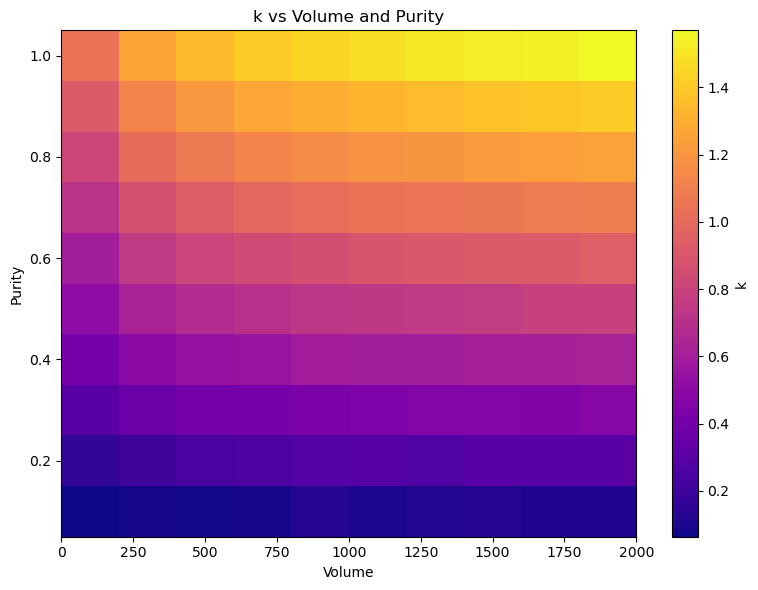

Figure 3: Heatmap showing relationship between k, Purity (p) and Volume (v) for a sphere


In [46]:
graph3(v_data)
print('Figure 3: Heatmap showing relationship between k, Purity (p) and Volume (v) for a sphere')

# Conclusion

From the middle graph we can see that the shape of the sample and the probability that capture neutrons initiate further fissions both impact the multiplication factor k. For each shape (each line) the probability equally affects the mean k value and because the overall slope is increasing for all the lines we can see that there is a clear linear relationship between p and k.

Looking at all the graphs above that we can see that the shape of the sample does impact the multiplication factor k. The best and most ideal shape would be a sphere followed by a cube and a cylinder where h=r. The closer a shape is to a sphere the better it is. The closer it is to a pole/long cylinder, the worse it is.

We can also see that between the first 4 graphs there isnt the greatest change/difference but in the middle graph, the difference between a low p value and high p value is massive. This could be further investigated by choosing more extreme shapes such as a cylinder with a radius of 1 but the purity of the Uranium sample is a much more impactful varriable.

Interstingly from the last graph we can see that the imapct of volume onto k is incredibly less than the impact of the purity. When the volume is around its minimum values we can see it just start to have an impact of k but overall its impact is nothing near the purity of our Uranium-235.

# Code validation

Below shows two graphs, one with a high range of volumes and the other with a small range. We can clearly tell that volume does impact the mean of k but the overall pattern is constant regardless of size. Thats why this project keeps its consistent.

![](codevalidation1.png)

We can see two graphs below, one has a large number of trials and the otehr small. These graphs show that 150 trials/simulations is enough to get the results of 300 or even more. It shows that 150 will give us accurate enough results.

![](codevalidation2.png)